# 02_Feature_Engineering.ipynb

## Imports

In [21]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

## Constants

Global constants and file paths are defined.

In [22]:
CLEANED_DATASET_PATH = Path.cwd().parent / "data" / "processed"

## Tools

Objects and tools that will be used repeatedly in the process are initialized.

## Loading Data
Cleaned data is loaded.

In [23]:
def load_data(file_path: Path, dataset_name: str) -> pd.DataFrame:
    """
    Load the dataset from the specified file path.

    Args:
        file_path (Path): The path to the dataset file.
        dataset_name (str): The name of the dataset to load.
    Returns:
        pd.DataFrame: The loaded dataset as a pandas DataFrame.
    """
    csv_path = file_path / dataset_name
    if not csv_path.exists():
        raise FileNotFoundError(f"The dataset file '{dataset_name}' does not exist at the specified path: {file_path}")
    return pd.read_csv(csv_path)

In [24]:
data = load_data(CLEANED_DATASET_PATH, "Housing_cleaned.csv")

In [25]:
data.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


## Correlation

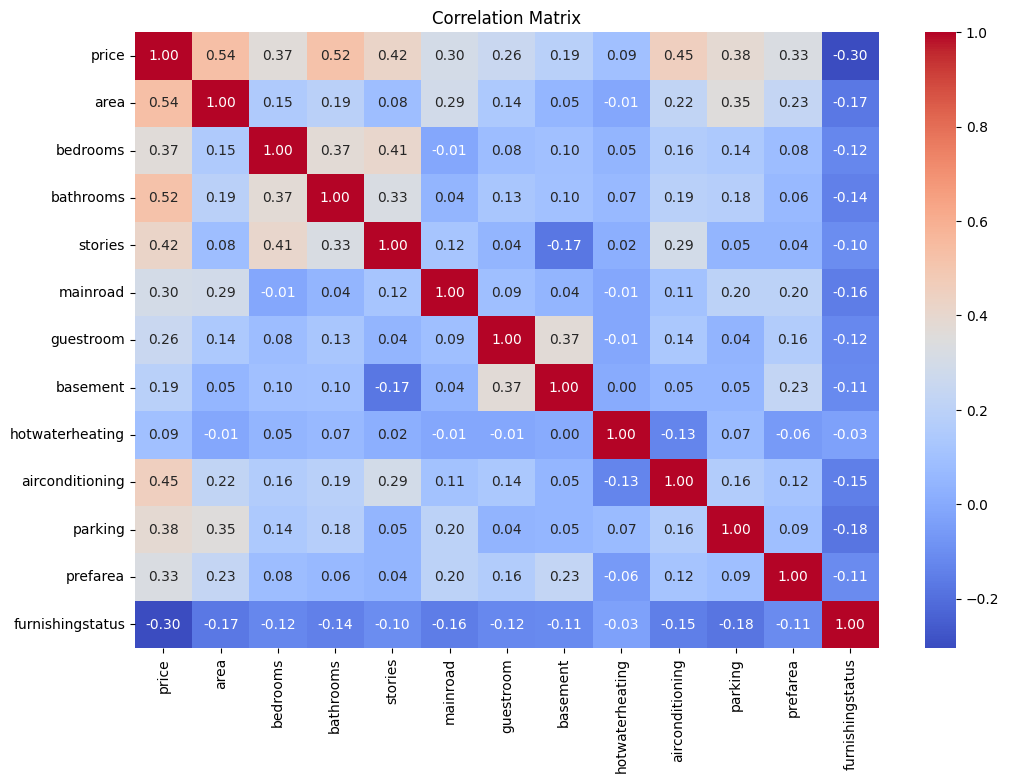

In [26]:
correlation_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()



The presented correlation matrix illustrates the relationships between property features and their price. The primary factors increasing a home's value are its area (0.54), the number of bathrooms (0.52), and the presence of airconditioning (0.45). The negative correlation observed for furnishingstatus (-0.30) is due to lower furnishing standards (e.g., unfurnished) being encoded with higher numerical values. The dataset is of high quality, showing no harmful multicollinearity among the features and no signs of data leakage.

## Splitting into target and traning set

In [27]:
target_data = data['price']
training_data = data.drop(columns=['price'])
